# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Loista Amanda Noviar
- **Email:** loistamnd1124@gmail.com
- **ID Dicoding:** loistamnd1124

## Tujuan Analisis

Proyek ini berfokus pada analisis pola penggunaan layanan bike sharing dengan berdasarkan pada faktor cuaca dan waktu.

## Menentukan Pertanyaan Bisnis

Berdasarkan dataset Bike Sharing, berikut merupakan pertanyaan bisnis yang ingin dijawab:

- Pertanyaan 1: Bagaimana perbedaan jumlah penyewa sepeda di berbagai kondisi cuaca selama rentang tahun 2011-2012, dan kondisi cuaca yang paling optimal untuk meningkatkan jumlah penggunaan?
- Pertanyaan 2: Pada jam berapa terjadinya lonjakan penyewaan sepeda dalam satu hari dalam rentang tahun 2011-2012, dan bagaimana pola tersebut dapat mempengaruhi perilaku mobilitas pengguna?

## Import Semua Packages/Library yang Digunakan

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

## Data Wrangling

### Gathering Data

Pada tahap ini dilakukan proses pengumpulan data dengan membaca dataset dari file CSV.

In [29]:
df_day = pd.read_csv('data/day.csv')
df_hour = pd.read_csv('data/hour.csv')

In [30]:
df_day.head(
    
)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [31]:
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- dataset berhasil dimuat tanpa adanya kendala
- Terdapat dua jenis data dari dua dataset yang berbeda yaitu: data harian dan data per jam
- Dataset ini berisikan fitur penting seperti season(cuaca), temp(suhu), dan registered(jumlah penyewaan)

### Assessing Data

tahap ini bertujuan untuk mengevaluasi kualitas data, seperti pengecekan missing values, tipe data, dan duplikasi.

In [32]:
df_day.info()
df_day.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [33]:
df_day.duplicated().sum()

np.int64(0)

**Insight:**
- tidak ditemukan data yang hilang (missing values)
- tidak terdapat data duplikat
- sebagian besar tipe data sudah sesuai
- kolom tanggal masih perlu perbaikan agar dapat digunakan dalam anilisis berbasis waktu

In [34]:
df_hour.info()
df_hour.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [35]:
df_hour.duplicated().sum()

np.int64(0)

**Insight:**
- tidak ditemukan data yang hilang (missing values) pada dataset hour
- Dataset Hour memiliki jumlah data yang lebih banyak dibandingkan dataset day karena mencatat aktivitas penyewaan disetiap jam
- tidak terdapat data duplikat
- kolom tanggal masih perlu perbaikan agar dapat digunakan dalam anilisis berbasis waktu
- dataset hour memiliki tingkat granulatitas yang tinggi sehingga coco untuk analisis pola penggunaan berdasarkan waktu

### Cleaning Data

Pada tahap ini dilakukan perbaikan data seperti konversi tipe data dan penanganan missing values.

In [36]:
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

**Insight:**
- kolom tanggal sudah diperbaiki dengan cara dikonversi ke format data datetime
- Dataset sudah siap digunakan untuk Exploratory Data Analysis (EDA)

## Exploratory Data Analysis (EDA)

Tahap ini dilakukan untuk memahami karakteristik data dan menemukan pola awal.

### Explore Dataset Day

In [37]:
df_day.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


**Insight:**
- Terdapat perbedaan variasi yang signifikan dalam jumlah penyewaan sepeda tiap harinya
- Faktor eksternal seperti cuaca dan suhu memungkinkan dalam mempengaruhi jumlah penyewa sepeda per harinya

### Explore Dataset Hour

In [38]:
df_hour.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


**Insight:**
- Dataset Hour menunjukan variasi jumlah penyewaan yang cukup tinggi dalam satu hari
- Nilai maksimum penyewaan per jam jauh lebih kecil dibandingkan dengan data Day, namun data hour memberikan detail pola penyewaan yang lebih spesifik
- Rata-rata penyewaan menunjukan adanya fluktuasi yang signifikan antar jam nya
- Hal ini mengindikasikan bahwa waktu(jam) merupakan salah satu faktor yang mempengaruhi intensitas penggunaan dan penyewaan sepeda

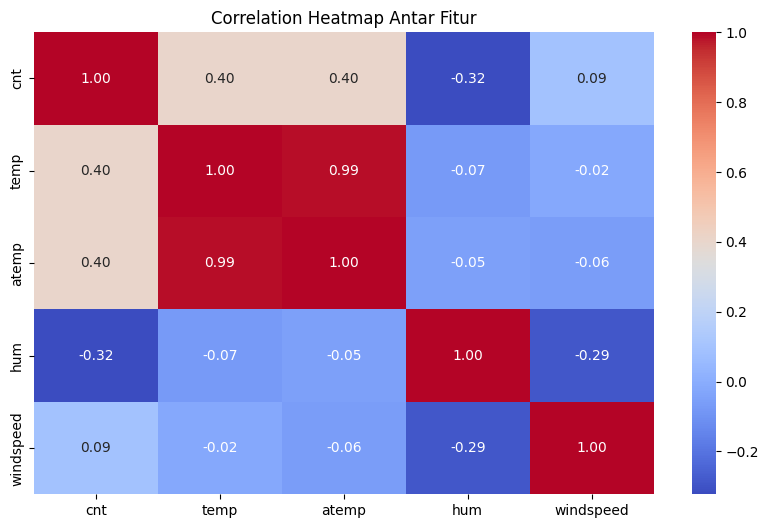

In [ ]:
plt.figure(figsize=(10,6))

corr = df_hour[['cnt','temp','atemp','hum','windspeed']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap Antar Fitur")
plt.show()

**Insight:**
- Temperatur (temp dan atemp) memiliki kolerasi yang positif terhadap jumlah penyewaan sepeda
- kelembabab (hum) memiliki korelasi yang negatif terhadap jumlah penyewaan
- kecepatan angin (windspeed) tidak menunjukan pengaruh yang signifikan terhadap jumlah penyewaan sepeda
- Hal ini menunjukan bahwa faktor lingkungan, terutama suhu dan kelembaban memiliki pengaruh terhadap pola penggunaan sepeda

## Visualization & Explanatory Analysis

Visualisasi dilakukan untuk menjawab pertanyaan bisnis yang telah ditentukan.

### Pertanyaan 1: Bagaimana kondisi cuaca dapat mempengaruhi jumlah penyewaan sepeda?

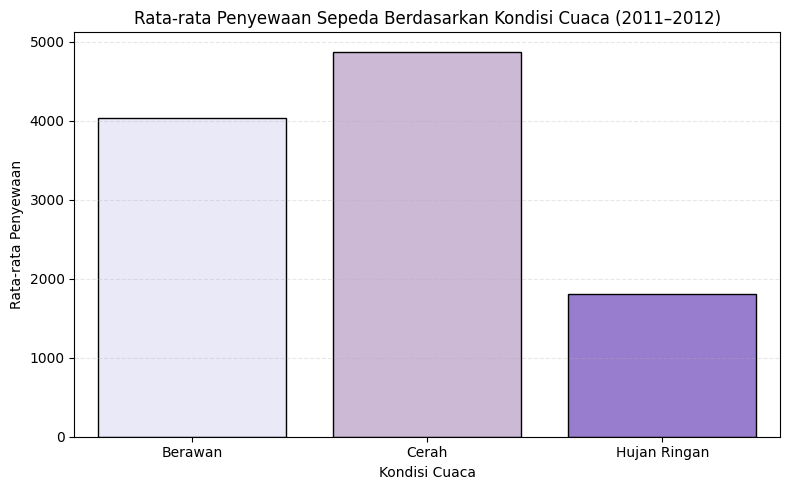

In [44]:
weather_map = {
    1:"Cerah", 
    2:"Berawan", 
    3:"Hujan Ringan"
}

df_day['weather'] = df_day['weathersit'].map(weather_map)

weather_group = df_day.groupby('weather')['cnt'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=weather_group,
    x='weather',
    y='cnt',
    palette=['#E6E6FA','#CDB4DB','#9370DB','#4B0082'],
    edgecolor='black'
)

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca (2011–2012)")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewaan")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**insight:**
- Kondisi cuaca sangat berdampak terhadap jumlah penyewaan sepeda 
- Cuaca cerah merupakan kondisi yang paling optimal dengan rata-rata penyewaan tertinggi 
- Pada cuaca berawan rata-rata penyewaan masih relatif tinggi akan tetapi mulai terjadi penurunan 
- Cuaca buruk menyebabkan penurunan penyewaan secara drastis menjadi faktor penghambat utama penggunaan sepeda 
- Penggunaan sepeda cenderung lebih aktif dalam kondisi cuaca yang mendukung

### Pertanyaan 2: Kapan jumlah penyewaan sepeda tertinggi berdasarkan waktu (jam)?

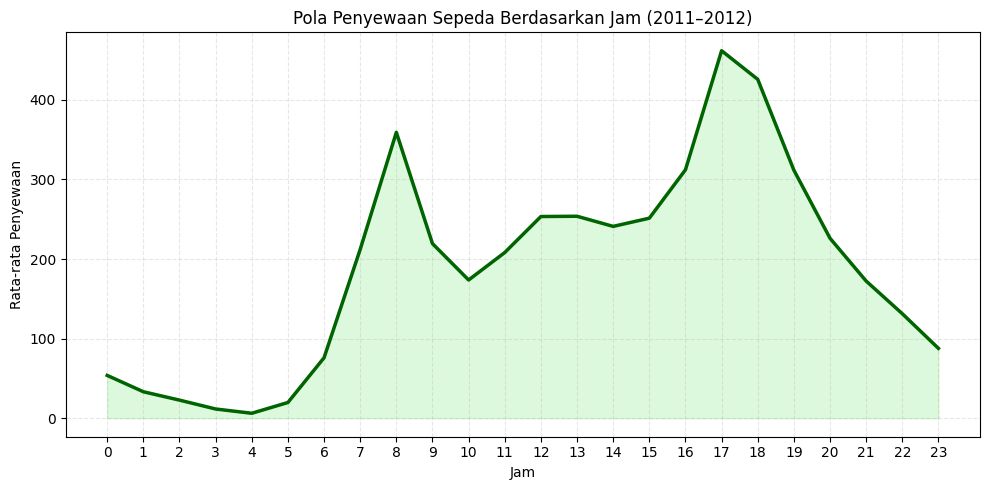

In [45]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=hour_group,
    x='hr',
    y='cnt',
    color='#006400',
    linewidth=2.5
)

plt.fill_between(
    hour_group['hr'],
    hour_group['cnt'],
    color='#90EE90',
    alpha=0.3
)

plt.title("Pola Penyewaan Sepeda Berdasarkan Jam (2011–2012)")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.xticks(range(0,24))
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Insight:**
- Apabila diperhatikan data penyewaan sepeda sepanjang hari terdapat dua momen sibuk yang cukup mencolok yaitu pada pagi hari yaitu: 
    1.  Pukul 07.00 sampai 09.00.
    2.  Kemudian di sore hari sekitar pukul 16.00 sampai dengan 18.00. 

- Rentang waktu ini bukan suatu kebetulan. pola ini terlalu konsisten untuk dikatakan sebagai sebuah kebetulan. berdasarkan jamnya menunjukkan bahwa sepeda digunakan sebagai moda transportasi harian bagi orang untuk berangkat maupun pulang dari tempat kerja.

- Sebaliknya ketika di luar jam tersebut aktivitas penyewaan mulai menurun terutama pada malam hari.

- Dari data yang kita dapat di atas maka dapat ditarik kesimpulan bahwa waktu bukan sekedar latar belakang, akan tetapi merupakan faktor yang sangat berpengaruh.

## Analisis Lanjutan (Opsional)

Pengelompokan kategori dimulai dari Low, Medium, serta High menggunakan pendekatan quantile dilakukan dengan tujuan untuk mengelompokkan 3 kelompok yang proporsional, sehingga kategori-kategori tersebut dapat mempresentasikan tingkat penggunaan sepeda secara akurat dan sesuai dengan distribusi data yang ada

In [54]:
# =========================
# CLUSTERING (BINNING)
# =========================

# menentukan batas kategori berdasarkan distribusi data
q1 = df_hour['cnt'].quantile(0.33)
q2 = df_hour['cnt'].quantile(0.66)

def kategori(cnt):
    if cnt <= q1:
        return "Low"
    elif cnt <= q2:
        return "Medium"
    else:
        return "High"

df_hour['kategori'] = df_hour['cnt'].apply(kategori)


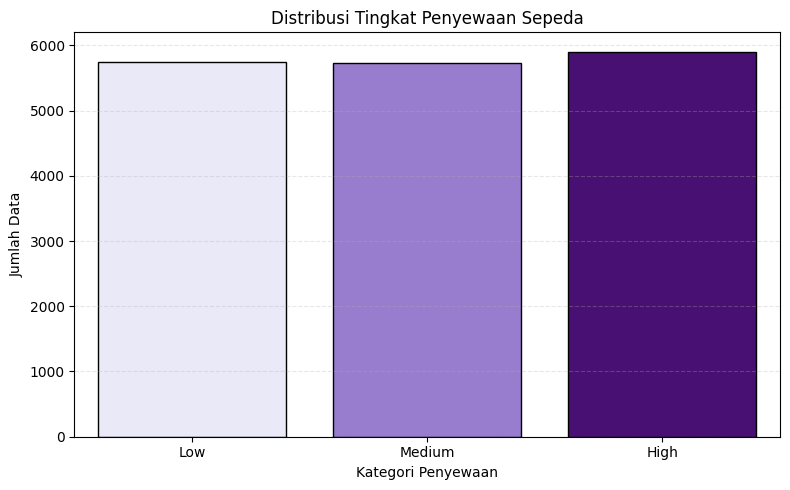

In [55]:
# =========================
# VISUALISASI DISTRIBUSI
# =========================

kategori_group = df_hour['kategori'].value_counts().reset_index()
kategori_group.columns = ['kategori', 'jumlah']

order = ['Low', 'Medium', 'High']

kategori_group['kategori'] = pd.Categorical(
    kategori_group['kategori'],
    categories=order,
    ordered=True
)

kategori_group = kategori_group.sort_values('kategori')

plt.figure(figsize=(8,5))

sns.barplot(
    data=kategori_group,
    x='kategori',
    y='jumlah',
    palette=['#E6E6FA','#9370DB','#4B0082'],
    edgecolor='black'
)

plt.title("Distribusi Tingkat Penyewaan Sepeda")
plt.xlabel("Kategori Penyewaan")
plt.ylabel("Jumlah Data")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**insight:**
- Data penyewaan sepeda dapat dikelompokkan ke dalam tiga kategori utama, kategori tersebut ialah low, medium serta high, yang tiap kategorinya memperlihatkan seberapa intens sepeda digunakan dalam kondisi tertentu.
- Kategori high merupakan kategori yang paling menarik untuk dikaji lebih lanjut. peningkatan penggunaan pada kategori ini tidak terjadi secara random akan tetapi cenderung muncul dalam rentang waktu yang dapat diprediksi yaitu pada pagi dan sore hari ketika aktivitas masyarakat sedang berada di puncaknya. selain dari faktor waktu, kondisi cuaca juga menjadi sangat berpengaruh terhadap intensitas penggunaan sepeda, seperti ketika cuaca cerah tingkat penyewaan memiliki rata-rata tertinggi.
- Berbanding terbalik dengan kategori low. jumlah penjualan sepeda dalam kategori low cenderung rendah hal ini umumnya terjadi ketika cuaca yang buruk atau di luar rentang waktu sibuk masyarakat. 
- Pola ini menandakan bahwa tinggi atau rendahnya tingkat penggunaan sepeda tidak hanya dijelaskan oleh satu faktor saja waktu serta kondisi cuaca saling berkaitan satu sama lain dalam menentukan seberapa besar tingkat penyewaan sepeda pada cuaca dan waktu tertentu.

## Conclusion

1. Hasil analisis data bike sharing selama periode 2011 sampai dengan 2012 menunjukkan penggunaan sepeda tidak hanya terjadi begitu saja terdapat pola yang terbentuk melalui keterkaitan antara kondisi lingkungan serta kebiasaan pengguna itu sendiri. 

2. Terdapat suatu penemuan yang menonjol dalam hasil analisis ini ialah pengaruh cuaca terhadap keputusan pengguna ketika cuaca cerah serta kondisi yang mendukung jumlah penyewa cenderung meningkat secara drastis. dan sebaliknya pada hujan atau cuaca buruk. hai ini menunjukkan bahwa kenyamanan serta rasa aman sangat menjadi pertimbangan yang tidak bisa diabaikan oleh pengguna sepeda. 

3. Selain berdasarkan cuaca ditemukan juga pola yang cukup konsisten pada waktu-waktu tertentu naiknya penggunaan sepeda, yaitu pada pagi dan sore hari. 

4. Faktor cuaca dan waktu saling mempengaruhi satu sama lain untuk menentukan tingkat penggunaan sepeda contohnya penggunaan tertinggi muncul ketika jam sibuk bertepatan dengan cuaca yang cerah sebaliknya jika diluar jam sibuk dan cuaca yang tidak bersahabat.

5. dari hasil analisis di atas ini menegaskan bahwa layanan Biken sharing mempunyai pola penggunaan yang bisa diprediksi. Hal ini sangat berguna dalam pengambilan keputusan operasi.

pada tahap ini data yang sudah clean disimpam untuk kebutuhan pembuatan dashboard

In [57]:
df_day.to_csv('dashboard/main_day_data.csv', index=False)
df_hour.to_csv('dashboard/main_hour_data.csv', index=False)